In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
#pip install openpyxl

In [3]:
df=pd.read_excel("University_Clustering.xlsx")
df.head(4)

,Univ,State,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,Brown,RI,1310,89,22,13,22704,94
1,CalTech,CA,1415,100,25,6,63575,81
2,CMU,PA,1260,62,59,9,25026,72
3,Columbia,NY,1310,76,24,12,31510,88


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Univ      25 non-null     object
 1   State     25 non-null     object
 2   SAT       25 non-null     int64 
 3   Top10     25 non-null     int64 
 4   Accept    25 non-null     int64 
 5   SFRatio   25 non-null     int64 
 6   Expenses  25 non-null     int64 
 7   GradRate  25 non-null     int64 
dtypes: int64(6), object(2)
memory usage: 1.7+ KB


In [5]:
new_df=df.drop(["Univ","State"],axis=1)
new_df.head()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,1310,89,22,13,22704,94
1,1415,100,25,6,63575,81
2,1260,62,59,9,25026,72
3,1310,76,24,12,31510,88
4,1280,83,33,13,21864,90


In [6]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x_new=pd.DataFrame(ss.fit_transform(new_df),columns=new_df.columns)

In [7]:
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage

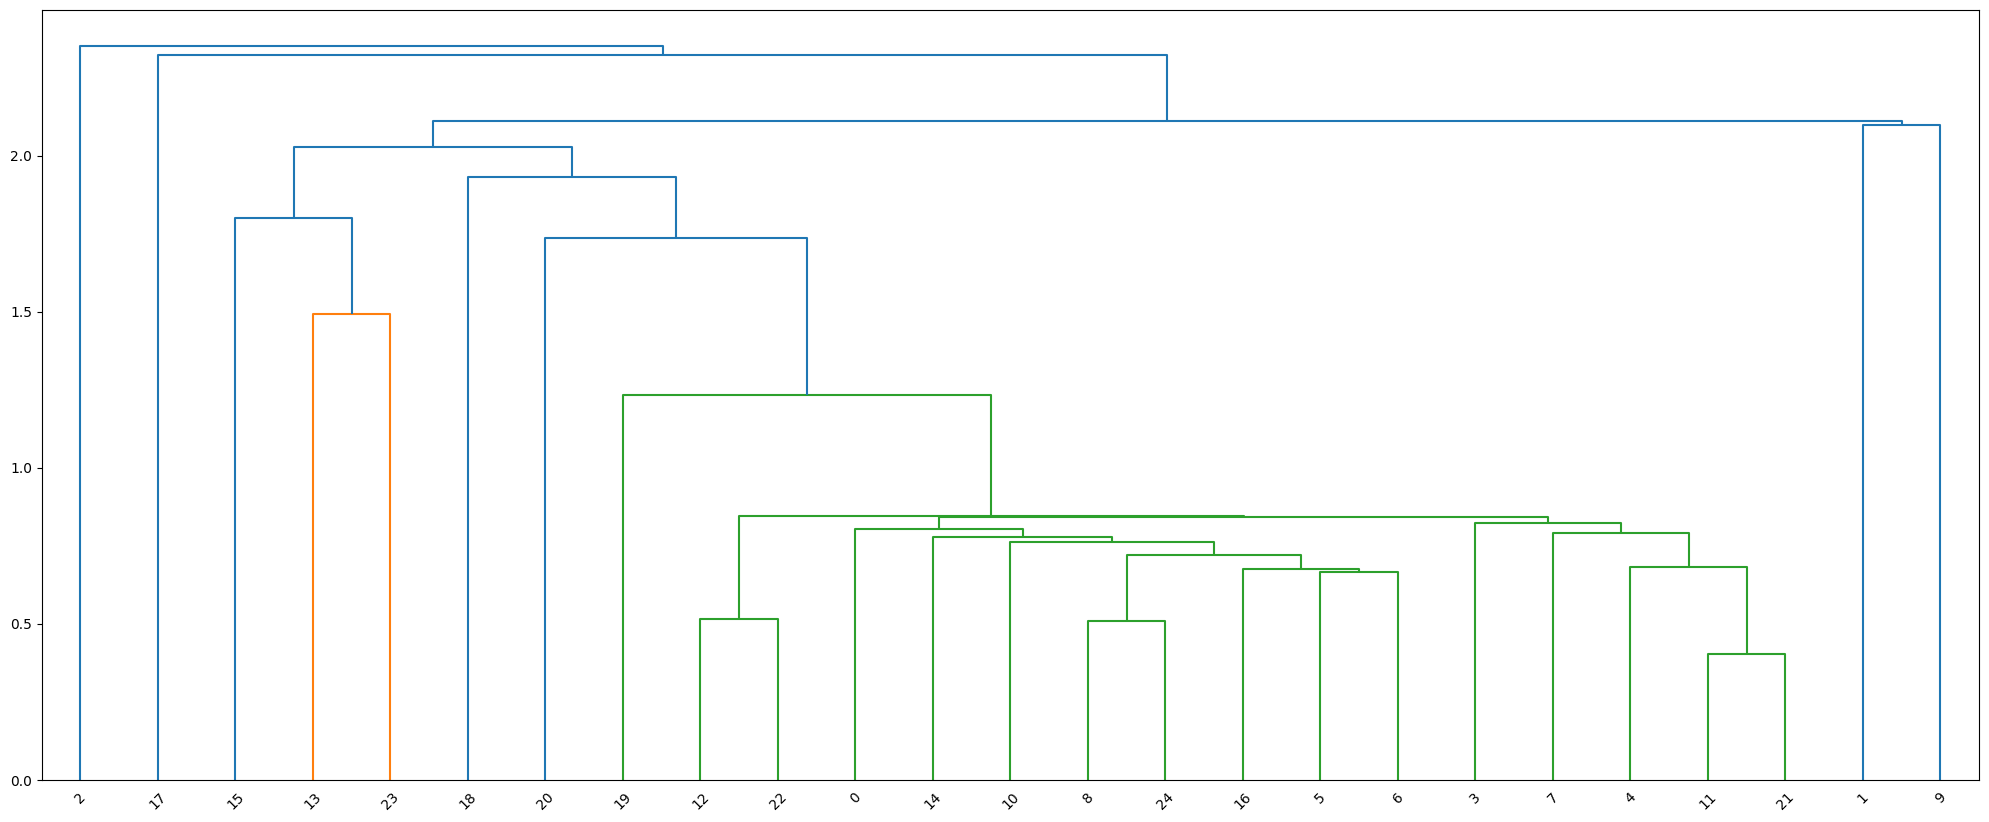

In [8]:
Z = linkage(x_new)
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z)
plt.show()

In [9]:
from sklearn.cluster import AgglomerativeClustering
model=AgglomerativeClustering(n_clusters=3)
model.fit(x_new)
model.labels_

array([2, 0, 2, 2, 2, 0, 0, 2, 0, 0, 0, 2, 2, 1, 0, 1, 0, 1, 2, 2, 2, 2,
       2, 1, 0])

In [10]:
df["target"]=model.labels_

In [11]:
df.head()

,Univ,State,SAT,Top10,Accept,SFRatio,Expenses,GradRate,target
0,Brown,RI,1310,89,22,13,22704,94,2
1,CalTech,CA,1415,100,25,6,63575,81,0
2,CMU,PA,1260,62,59,9,25026,72,2
3,Columbia,NY,1310,76,24,12,31510,88,2
4,Cornell,NY,1280,83,33,13,21864,90,2


In [12]:
df["target"].value_counts()

target
2    12
0     9
1     4
Name: count, dtype: int64

In [14]:
df[df["target"]==2]["Univ"]

0            Brown
2              CMU
3         Columbia
4          Cornell
7       Georgetown
11    Northwestern
12       NotreDame
18      UCBerkeley
19        UChicago
20       UMichigan
21           UPenn
22             UVA
Name: Univ, dtype: object

In [15]:
df[df["target"]==0]["Univ"]

1          CalTech
5        Dartmouth
6             Duke
8          Harvard
9     JohnsHopkins
10             MIT
14       Princeton
16        Stanford
24            Yale
Name: Univ, dtype: object

In [16]:
df[df["target"]==1]["Univ"]

13     PennState
15        Purdue
17      TexasA&M
23    UWisconsin
Name: Univ, dtype: object

In [19]:
new_df.columns

Index(['SAT', 'Top10', 'Accept', 'SFRatio', 'Expenses', 'GradRate'], dtype='object')

In [20]:
from sklearn.decomposition import PCA

In [27]:
pca = PCA(n_components=3)
components=pca.fit_transform(new_df)
print(components)
print(pca.explained_variance_ratio_)

[[-4.68363650e+03  7.59712203e+01 -5.80091946e+00]
 [ 3.61872552e+04 -6.56606028e+01  3.11485493e+00]
 [-2.36202549e+03 -2.57815022e-01  2.27858526e+01]
 [ 4.12219319e+03  2.02621630e+01 -6.88636656e+00]
 [-5.52381143e+03  4.85379725e+01 -6.94342469e-01]
 [ 4.77437077e+03  4.84687896e+01 -3.55572840e+00]
 [ 4.19722979e+03  2.67600466e+01 -2.43822730e+00]
 [-7.26192660e+03  3.52275203e+01 -1.43204663e+01]
 [ 1.21375996e+04  6.44741319e+01 -3.15624961e+00]
 [ 3.13026647e+04 -1.49963047e+02 -3.79522155e+00]
 [ 7.48255440e+03  6.98072577e+01  1.16758889e+01]
 [ 6.63958605e+02 -8.13748385e+00 -2.49154800e+00]
 [-1.22658452e+04  6.27992888e+01  4.22195430e+00]
 [-1.72038246e+04 -8.63092702e+01 -1.69206378e+01]
 [ 2.83261913e+03  9.56603041e+01 -2.87765897e+00]
 [-1.83232881e+04 -1.62513865e+02  3.25903253e+00]
 [ 9.06241363e+03  4.27215569e+01 -3.56330839e+00]
 [-1.86848390e+04 -8.50361392e+01 -1.23090936e+00]
 [-1.22479251e+04  4.99943841e+01  4.62842947e+00]
 [ 1.09919327e+04 -4.51493360e+

In [28]:
from mpl_toolkits import mplot3d

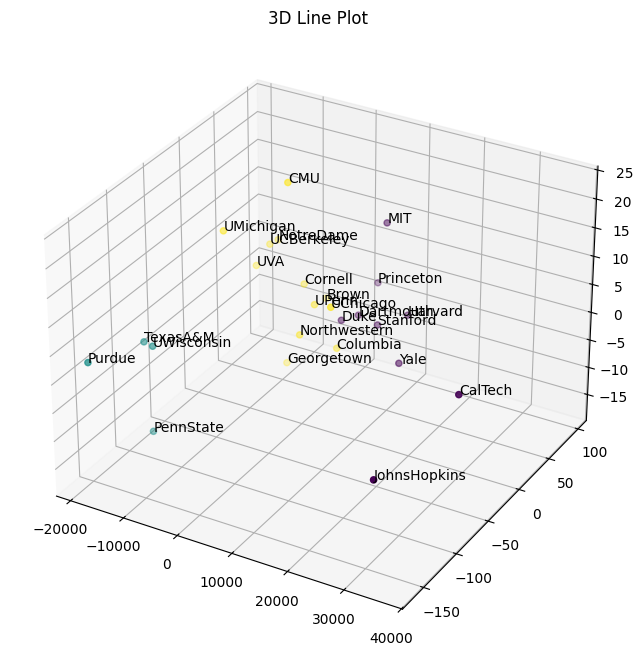

In [34]:
pc0=components[:,0]
pc1=components[:,1]
pc2=components[:,2]
fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection='3d')
ax.scatter(pc0,pc1,pc2,c=df["target"])
for i,u in enumerate(df["Univ"]):
    ax.text(pc0[i],pc1[i],pc2[i],u)
ax.set_title('3D Line Plot')
plt.show()

In [39]:
pca_df=pd.DataFrame(components,columns=["PC0","PC1","PC2"],index=new_df.index)

In [40]:
pca_df["Univ"]=df["Univ"]

In [41]:
pca_df.head(5)

,PC0,PC1,PC2,Univ
0,-4683.636503,75.971220,-5.800919,Brown
1,36187.255229,-65.660603,3.114855,CalTech
2,-2362.025493,-0.257815,22.785853,CMU
3,4122.193187,20.262163,-6.886367,Columbia
4,-5523.811429,48.537972,-0.694342,Cornell


In [43]:
df.head()

,Univ,State,SAT,Top10,Accept,SFRatio,Expenses,GradRate,target
0,Brown,RI,1310,89,22,13,22704,94,2
1,CalTech,CA,1415,100,25,6,63575,81,0
2,CMU,PA,1260,62,59,9,25026,72,2
3,Columbia,NY,1310,76,24,12,31510,88,2
4,Cornell,NY,1280,83,33,13,21864,90,2
